<a href="https://colab.research.google.com/github/DanDC25/Statistical-Learning-with-Python/blob/in_progress/DSA211_05_Lab_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSA211 Statistical Learning

## Lab 5: Logistic Regression in Python

**Learning objectives**

By the end of this lab, students will be able to:

1. Construct a binary outcome variable and interpret the class distribution in terms of the modelling challenge it poses.
2. Fit simple and multiple logistic regression models using `statsmodels` and interpret coefficients on the log-odds and odds ratio scales.
3. Generate predicted probabilities and convert them to class labels via a chosen threshold.
4. Apply the likelihood ratio test to compare nested logistic models.
5. Construct a confusion matrix and compute sensitivity, specificity, precision, and accuracy.
6. Select a classification threshold based on the relative cost of false positives and false negatives.
7. Plot and interpret the ROC curve, AUC, and precision-recall curve.
In this lab we fit binary logistic regression models to predict whether a car seat sells at **high** volume. We use `statsmodels` throughout: this week the objective is inference. The prediction-focused `sklearn` workflow, and the contrast between the two, arrive in Week 7 alongside cross-validation.

The dataset is **Carseats** (400 observations, 11 variables). The outcome `High` is derived from `Sales`: `High = 1` if `Sales > 8` (thousands of units), else `High = 0`.

***

## Setup

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from scipy.stats import chi2

***

# Part 0: EDA

In [53]:
carseats = pd.read_csv(
    'https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Carseats.csv'
)
carseats.index = range(1, len(carseats) + 1)

print(carseats.shape)
carseats.head()

(400, 11)


,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
1,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
2,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
3,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
4,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
5,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [54]:
carseats.dtypes

,0
Sales,float64
CompPrice,int64
Income,int64
Advertising,int64
Population,int64
Price,int64
ShelveLoc,object
Age,int64
Education,int64
Urban,object


In [55]:
carseats.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


Logistic regression requires the variable to be boolean [0,1]. The regression itself will predict the likelihood of the outcome based on the predictors. Below we create a binary varaible `High` based on `Sales`.

In [56]:
# Create binary outcome
carseats['High'] = (carseats['Sales'] > 8).astype(int)
print('Class distribution:')
print(carseats['High'].value_counts())
print(f'\nPositive class rate: {carseats["High"].mean():.3f}')

Class distribution:
High
0    236
1    164
Name: count, dtype: int64

Positive class rate: 0.410


> The outcome `High` is defined as `Sales > 8`. This threshold is drawn from the ISLP textbook and sits close to the median of `Sales` (~7.5), producing a roughly balanced split (41% of stores are classified as high-sales). This balance is intentional: it avoids the class imbalance issues seen in the Default dataset and allows accuracy to remain a meaningful metric alongside sensitivity and specificity.

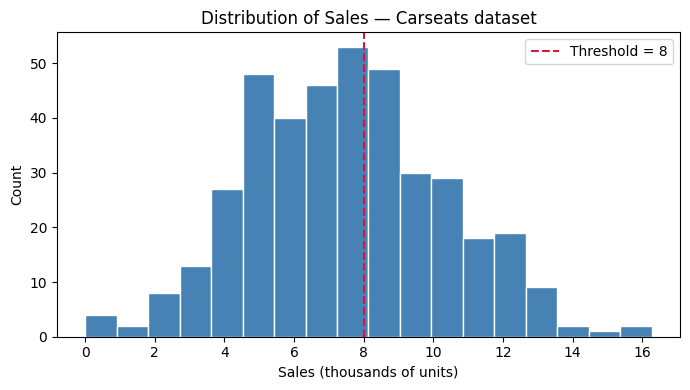

In [57]:
# Distribution of Sales with threshold marked
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(carseats['Sales'],
        bins=18,
        color='steelblue',
        edgecolor='white')
ax.axvline(8,
           color='crimson',
           ls='--',
           lw=1.5,
           label='Threshold = 8')
ax.set_xlabel('Sales (thousands of units)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Sales — Carseats dataset')
ax.legend()
plt.tight_layout()
plt.show()

`Sales` is roughly symmetric and bell-shaped, with the threshold of 8 falling just above the centre of the distribution.

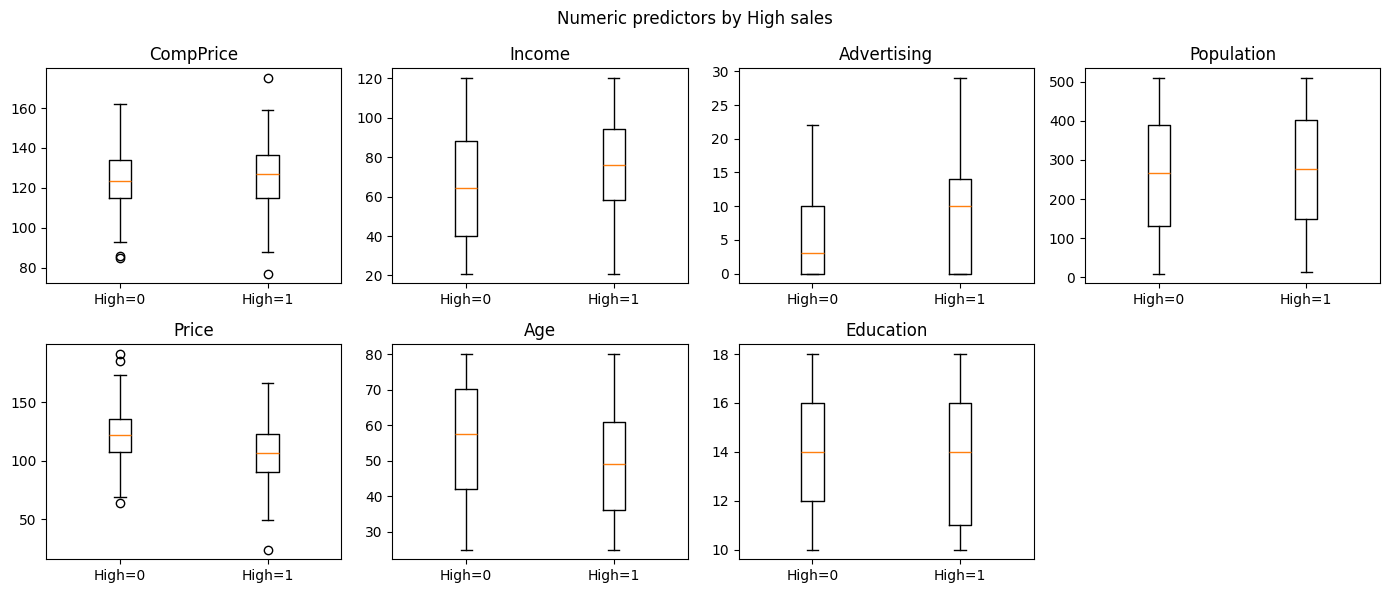

In [58]:
# Boxplots of numeric predictors by High
numeric_cols = ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    data_0 = carseats.loc[carseats['High'] == 0, col]
    data_1 = carseats.loc[carseats['High'] == 1, col]
    axes[i].boxplot([data_0, data_1],
                    tick_labels=['High=0', 'High=1'])
    axes[i].set_title(col)
axes[-1].axis('off')
fig.suptitle('Numeric predictors by High sales')
plt.tight_layout()
plt.show()

**Price** and **Advertising** stand out clearly.

**Price**: Lower-priced car seats sell at higher volume, which is intuitive.

**Advertising**: `High=1` stores have higher advertising spend, suggesting that marketing investment is associated with higher sales.

**Age**: Younger customer bases are associated with higher sales, plausible for a child product.

**CompPrice**, **Income**, **Education**, and **Population** show very little separation between the two groups. Likely weak predictors.

In [59]:
# Categorical predictors: ShelveLoc, Urban, US
cat_cols = ['ShelveLoc', 'Urban', 'US']
for col in cat_cols:
    ct = pd.crosstab(carseats[col], carseats['High'], normalize='index').round(3)
    ct.columns = ['High=0', 'High=1']
    print(f'--- {col} ---')
    print(ct)
    print()

--- ShelveLoc ---
           High=0  High=1
ShelveLoc                
Bad         0.854   0.146
Good        0.224   0.776
Medium      0.616   0.384

--- Urban ---
       High=0  High=1
Urban                
No      0.542   0.458
Yes     0.610   0.390

--- US ---
     High=0  High=1
US                 
No    0.711   0.289
Yes   0.523   0.477



**ShelveLoc** is the standout. Stores with good shelf placement have a 77.6% high-sales rate versus 14.6% for bad placement. The strongest signal in the entire dataset by a wide margin.

**US** stores have a 47.7% high-sales rate versus 28.9% for non-US stores, suggesting the US market is more favourable for high sales.

**Urban** shows little separation with 45.8% vs 39.0%, likely not a useful predictor.

***

# Part 1: Fitting Logistic Regression

## 1.1 Simple logistic regression

We start with `Price` as the sole predictor of `High`. This is the worked demo. Read through the output carefully before moving to the exercise.

In [60]:
# Demo: simple logistic regression — Price only
model_simple = smf.logit('High ~ Price',
                         data=carseats).fit()
print(model_simple.summary())

Optimization terminated successfully.
         Current function value: 0.613395
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   High   No. Observations:                  400
Model:                          Logit   Df Residuals:                      398
Method:                           MLE   Df Model:                            1
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                 0.09376
Time:                        14:43:28   Log-Likelihood:                -245.36
converged:                       True   LL-Null:                       -270.74
Covariance Type:            nonrobust   LLR p-value:                 1.038e-12
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.5228      0.605      5.823      0.000       2.337       4.709
Price         -0.0340      0.

In [61]:
# Odds ratio and 95% CI for Price
conf_simple = model_simple.conf_int(alpha=0.05) # extract CI
conf_simple.columns = ['CI lower', 'CI upper']
or_simple = pd.DataFrame({
    'Coef (log-odds)': model_simple.params,
    'OR':              np.exp(model_simple.params),
    'OR CI lower':     np.exp(conf_simple['CI lower']),
    'OR CI upper':     np.exp(conf_simple['CI upper'])
})
print(or_simple.round(4))

           Coef (log-odds)       OR  OR CI lower  OR CI upper
Intercept           3.5228  33.8792      10.3499     110.8992
Price              -0.0340   0.9666       0.9567       0.9766


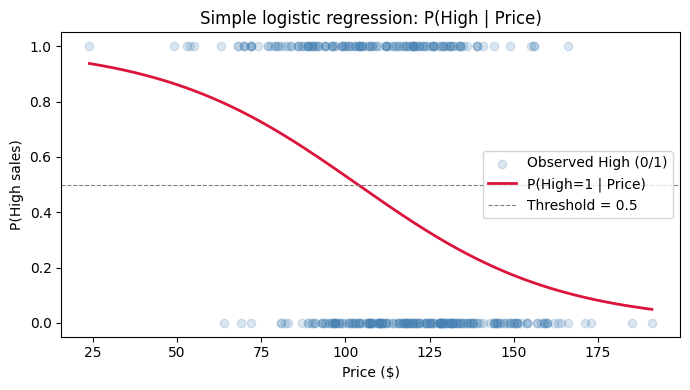

In [62]:
# Predicted probability curve over the range of Price
price_range = np.linspace(carseats['Price'].min(), carseats['Price'].max(), 300)
pred_prob_simple = model_simple.predict(pd.DataFrame({'Price': price_range}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(carseats['Price'], carseats['High'],
           alpha=0.2,
           color='steelblue',
           label='Observed High (0/1)')
ax.plot(price_range,
        pred_prob_simple,
        color='crimson',
        lw=2,
        label='P(High=1 | Price)')
ax.axhline(0.5,
           color='grey',
           ls='--', lw=0.8,
           label='Threshold = 0.5')
ax.set_xlabel('Price ($)')
ax.set_ylabel('P(High sales)')
ax.set_title('Simple logistic regression: P(High | Price)')
ax.legend()
plt.tight_layout()
plt.show()

❓ **Question 1.1.** Interpret the outputs in this section.

*Your answer here:*

In the plot, it can be observed that prices and probability of high sales have a non-linear negative relationship; specifically, as prices increases, the probability of carseats sales being more than 8000 units decreases.

## 1.2 Multiple logistic regression

Fit a multiple logistic regression model predicting `High` from all predictors **except** `Sales` (which was used to construct `High`). Use `C()` notation for categorical variables. The categorical columns are `ShelveLoc` (reference level: `Bad`), `Urban`, and `US`.

### Exercise 1.2a: Fit the multiple logistic regression model

In [63]:
### YOUR CODE HERE
# Fit model_full using smf.logit() with formula:
# 'High ~ CompPrice + Income + Advertising + Population + Price + Age + Education + C(ShelveLoc) + C(Urban) + C(US)'
# Print the summary

model_full = smf.logit("High ~ CompPrice + Income + Advertising + Population + Price + Age + Education + C(ShelveLoc) + C(Urban) + C(US)", data=carseats).fit()
print(model_full.summary())

log_odds_price = model_full.params['Price'].round(4)
odds_ratio_price = np.exp(log_odds_price).round(4)
odds_ratio_price_1k = np.exp(log_odds_price*1000).round(4)
print(f"Log odds of price is {log_odds_price}, Odds ratio of price is {odds_ratio_price}, Odds ratio of $1000 change in price is {odds_ratio_price_1k}")

Optimization terminated successfully.
         Current function value: 0.226845
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                   High   No. Observations:                  400
Model:                          Logit   Df Residuals:                      388
Method:                           MLE   Df Model:                           11
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.6649
Time:                        14:43:29   Log-Likelihood:                -90.738
converged:                       True   LL-Null:                       -270.74
Covariance Type:            nonrobust   LLR p-value:                 1.843e-70
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -5.0890      2.407     -2.114      0.034      -9.806      

❓ **Question 1.2a.** Interpret the following from the summary output:

- Which predictors are statistically significant at the 5% level?
- Interpret the coefficient on `Price` in terms of **(i)** log-odds and **(ii)** odds ratio. Comment on the size and sign.
- The reference level for `ShelveLoc` is `Bad`. Interpret the coefficient on `ShelveLoc[T.Good]` with respect to the size, sign, and odds ratio.

*Your answer here:*

1. The following predictors are statistically is significant at the 5% level:

C(ShelveLoc)[T.Good]: Good shelf location

C(ShelveLoc)[T.Medium]: Medium shelf location

CompPrice

Income

Advertising

Price

Age

2. Coefficient of Price (B-price) is the log-odds whereas the odd-ratio is the probability of categorizing carseats sales to be "High".

Interpreting the coefficient of Price (-0.1675) from the summary table in terms od log-odds and odd-ratio, each additional dollar increase in prices of carseats decreases the log-odds of categorizing as "High sales" by 0.1675. In terms of odd-ratio, each additional dollar increase in prices multiples the odd of being categorized as "High" sales approximately by 0.8458.


### Exercise 1.2b: Odds ratios and confidence intervals

In [64]:
### YOUR CODE HERE
# Compute and print the odds ratio table for model_full
# Include: OR, OR CI lower (2.5%), OR CI upper (97.5%)

conf_full = model_full.conf_int(alpha=0.05) # extract CI
conf_full.columns = ['CI lower', 'CI upper']

odds_ratio_table = pd.DataFrame({
    "Log Odds": model_full.params.round(4),
    "Odds_ratio": np.exp(model_full.params).round(4),
    "OR Lower CI": np.exp(conf_full['CI lower']),
    "OR Upper CI": np.exp(conf_full['CI upper'])
})
display(odds_ratio_table)

,Log Odds,Odds_ratio,OR Lower CI,OR Upper CI
Intercept,-5.0890,0.0062,0.000055,0.689500
C(ShelveLoc)[T.Good],8.2409,3792.9056,500.984141,28715.744397
C(ShelveLoc)[T.Medium],3.5970,36.4903,10.166232,130.976870
C(Urban)[T.Yes],-0.3828,0.6820,0.288302,1.613129
C(US)[T.Yes],-0.6986,0.4973,0.154931,1.596087
CompPrice,0.1725,1.1882,1.135097,1.243875
Income,0.0341,1.0347,1.018816,1.050860
Advertising,0.2957,1.3441,1.215675,1.486165
Population,-0.0009,0.9991,0.996308,1.001866
Price,-0.1675,0.8458,0.813865,0.878951


❓ **Question 1.2b.** Using the odds ratio table:

- Interpret the odds ratio for `ShelveLoc[T.Good]`. What does its size say about the effect of good shelf placement, and what does the width of its confidence interval say about how precisely that effect is estimated?
- Which predictors have a confidence interval that contains 1? Compare that set with the predictors you found insignificant in Question 1.2a, and explain why the two agree.

*Your answer here:*

The odds ratio of ShelveLoc[T.Good] is enormous compared to the other predictors. This implies that the effect of good shelf placement significant affects the probability of to be considered as "High" sales. The width of the confidence interval is also large, implying that the predictor has low precision.

Is the question supposed to be "1" or "0"? Because when a confidence interval contains 0, it is found to be statistically insignificant. The following predictors are statisticaly insignificant by examining if their individual Confidence Interval includes number 0

Predictors that are considered insignificant in Question 1.2a are also considered to be statistically insignificant in this question. The two method provide the same answer as they are complementary to each other. Determining confidence interval and p-value utilizes the same alpha (5%). Confidence level = 1-alpha whereas p value (if insignificant) > alpha.


***

# Part 2: Point Predictions

`model_full.predict()` returns predicted probabilities. The conversion to a class label is a separate step. The analyst applies a threshold based on the application context.

### Exercise 2.1: Predict for three new stores

In [65]:
### YOUR CODE HERE
# (a) Predict the probability of High sales for three new stores:
#     Store A: Price=100, CompPrice=110, Income=60, Advertising=10,
#              Population=200, Age=40, Education=12,
#              ShelveLoc='Good', Urban='Yes', US='Yes'
#     Store B: same as A but Price=130
#     Store C: same as A but ShelveLoc='Bad'
# (b) Apply threshold 0.5 to obtain a class prediction for each store
# (c) Print a table: Store | pred_prob | pred_class

new_stores = pd.DataFrame({
    'Price': [100, 130, 100],
    'CompPrice': [110, 110, 110],
    'Income': [60, 60, 60],
    'Advertising': [10, 10, 10],
    'Population': [200, 200, 200],
    'Age': [40, 40, 40],
    'Education': [12, 12, 12],
    'ShelveLoc': ['Good', 'Good', 'Bad'],
    'Urban': ['Yes', 'Yes', 'Yes'],
    'US': ['Yes', 'Yes', 'Yes']})

new_stores['Predicted Prob'] = model_full.predict(new_stores)

new_stores['Store_name'] = ['Store A', 'Store B', 'Store C']

new_stores['Predicted Class'] = ((new_stores['Predicted Prob'] >= 0.5)).astype(int)

#display(model_full.predict())

print(new_stores[['Store_name', 'Predicted Prob', 'Predicted Class']])

diff_a_c = (new_stores.loc[0, 'Predicted Prob']) - (new_stores.loc[2, 'Predicted Prob'])

print(f"Difference in Predicted Probability between Store A and C is {diff_a_c}")

  Store_name  Predicted Prob  Predicted Class
0    Store A        0.994770                1
1    Store B        0.555607                1
2    Store C        0.047755                0
Difference in Predicted Probability between Store A and C is 0.9470152974283459


❓ **Question 2.1.** Store C has the same predictors as Store A except for shelf location. How large is the difference in predicted probability between `ShelveLoc='Good'` and `ShelveLoc='Bad'`? Is this consistent with the odds ratio you computed in Part 1?

*Your answer here:*

The difference in predicted probability between Store A and Store C is large due to the difference in shelf location. The difference is approximately 0.9470153. The finding is consistent with part 1 because both parts show that compared to good shelf location, bad shelf location is significantly less likely to result in having carseats sales above 8000 units to be considered as "High".

***

# Part 3: Inference — Likelihood Ratio Test

- **Restricted model:** based on EDA
- **Full model:** `model_full` from Part 1

The LR statistic is $\Lambda = -2(\ell_\text{restricted} - \ell_\text{full}) \sim \chi^2_q$ under $H_0$, where $q$ is the number of additional parameters.

The LR test then compares `model_eda` (restricted) against `model_full` (full), testing whether the excluded predictors, `CompPrice`, `Income`, `Population`, `Education`, `Urban`, jointly add anything beyond what EDA already suggested.

> **Note:** This model was selected by inspecting the same data used to fit it. The LR test that follows is therefore not a *clean* inferential test. The predictors were chosen partly because they showed separation in the EDA. Treat the p-values as *indicative* rather than confirmatory. Formal predictor selection on held-out data is covered in Week 8.

In [66]:
# Restricted model based on EDA with predictors showing clear separation by High
model_eda = smf.logit(
    'High ~ Price + Advertising + Age + C(ShelveLoc) + C(US)',
    data=carseats
).fit()
print(model_eda.summary())

Optimization terminated successfully.
         Current function value: 0.375647
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   High   No. Observations:                  400
Model:                          Logit   Df Residuals:                      393
Method:                           MLE   Df Model:                            6
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.4450
Time:                        14:43:29   Log-Likelihood:                -150.26
converged:                       True   LL-Null:                       -270.74
Covariance Type:            nonrobust   LLR p-value:                 3.485e-49
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7.0977      1.126      6.303      0.000       4.891      

### Exercise 3.1: Compute the likelihood ratio test

In [67]:
### YOUR CODE HERE
# Compute the LR test statistic comparing model_eda to model_full
# Determine the degrees of freedom
# Compute and print the p-value using chi2.sf()

LR_stat = -2 * (model_eda.llf - model_full.llf)

df_diff = model_full.df_model - model_eda.df_model

p_value = chi2.sf(LR_stat, df_diff)

print(f"""LR test statistics is {LR_stat}
      Degrees of freedom for model_eda is {model_eda.df_model}
      Degrees of freedom for model_full is {model_full.df_model}
      P-value using chi square is {p_value}""")

LR test statistics is 119.04129908809031
      Degrees of freedom for model_eda is 6.0
      Degrees of freedom for model_full is 11.0
      P-value using chi square is 5.0092618948574896e-24


❓ **Question 3.1.** State your conclusion in one sentence.

*Your answer here:*

Utilizing the full model and all predictors results in having higher explanatory power for the variance in the data; this finding is statistically significant considering the p-value.


***

# Part 4: Confusion Matrix and Threshold Selection

## 4.1 Confusion matrix at threshold 0.5

In [68]:
# Demo: confusion matrix for model_simple at threshold 0.5
y_true        = carseats['High'] # Actual outcome, used many times later
y_prob_simple = model_simple.predict(carseats)
y_pred_simple = (y_prob_simple >= 0.5).astype(int)

cm_simple = confusion_matrix(y_true, y_pred_simple)
tn, fp, fn, tp = cm_simple.ravel()

print('Confusion Matrix — model_simple (Price only):')
print(pd.DataFrame(cm_simple,
                   index=['Actual Low', 'Actual High'],
                   columns=['Pred Low', 'Pred High']))
print()
print(f'Sensitivity: {tp / (tp + fn):.3f}')
print(f'Specificity: {tn / (tn + fp):.3f}')
print(f'Precision:   {tp / (tp + fp):.3f}')
print(f'Accuracy:    {(tp + tn) / len(y_true):.3f}')

Confusion Matrix — model_simple (Price only):
             Pred Low  Pred High
Actual Low        190         46
Actual High        92         72

Sensitivity: 0.439
Specificity: 0.805
Precision:   0.610
Accuracy:    0.655


### Exercise 4.1: Confusion matrix for the full model

In [69]:
### YOUR CODE HERE
# Compute the confusion matrix for model_full at threshold 0.5 (already done)
# Print sensitivity, specificity, precision, and accuracy

y_prob_full = model_full.predict(carseats)
y_pred_full = (y_prob_full >= 0.5).astype(int)

cm_full = confusion_matrix(y_true, y_pred_full)
tn, fp, fn, tp = cm_full.ravel()

print('Confusion Matrix — model_simple (Price only):')
print(pd.DataFrame(cm_full,
                   index=['Actual Low', 'Actual High'],
                   columns=['Pred Low', 'Pred High']))
print()
print(f'Sensitivity: {tp / (tp + fn):.3f}')
print(f'Specificity: {tn / (tn + fp):.3f}')
print(f'Precision:   {tp / (tp + fp):.3f}')
print(f'Accuracy:    {(tp + tn) / len(y_true):.3f}')


Confusion Matrix — model_simple (Price only):
             Pred Low  Pred High
Actual Low        221         15
Actual High        22        142

Sensitivity: 0.866
Specificity: 0.936
Precision:   0.904
Accuracy:    0.907


❓ **Question 4.1.** Compare the confusion matrices of `model_simple` and `model_full`. Which model makes more errors and of what type? Does accuracy fully capture the difference between the two models?

Note: the Carseats dataset is roughly balanced. Does this change how you interpret accuracy compared to the Default dataset from the lecture?

*Your answer here:*

Comparing between the two confusion matrices of model_simple and model_full, model_simple makes more error in every type

1. Sensitivity (given all actual correct, how many did the model correctly capture)

2. Specificity (given all actual incorrect, how many did the model flagged as incorrect)

3. Precision (of all flagged positives, how many are actual positives)

4. Accuracy (proportion of correct flags out of all predictions)

It appears that accuracy does fully capture the difference between the two model as the difference is accuracies is reflected in the significant differences in the other 3 error types.

Balance: Yes, I believe that a more balanced dataset (both classification High/Low are relatively close in size) will result in a higher accuracy especially with threshold at 0.5. Accuracy measures the proportion of correct flags out of all flags-predictions; with a more balanced dataset and a threshold of 0.5, the dataset breadth across high/low is relatively equal which the model is able to more accurately flag high/low datapoints. Hence, **higher accuracy**.

## 4.2 Threshold selection

In the context of predicting high-sales locations for a retailer, a **false negative** means failing to stock a location that would have sold well (a missed revenue opportunity). A **false positive** means over-stocking a location that turns out to be low-sales (excess inventory cost). The relative cost of these two errors determines the appropriate threshold.

Below, we compute the sensitivity and specificity for a selected set of threshold levels under the full model.

In [70]:
thresholds_to_try = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds_to_try:
    y_pred_t = (y_prob_full >= t).astype(int)
    cm_t = confusion_matrix(y_true, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rows.append({
        'Threshold':   t,
        'Sensitivity': round(tp_t / (tp_t + fn_t), 3),
        'Specificity': round(tn_t / (tn_t + fp_t), 3)
    })

print(pd.DataFrame(rows).to_string(index=False))

 Threshold  Sensitivity  Specificity
       0.2        0.963        0.826
       0.3        0.939        0.860
       0.4        0.896        0.894
       0.5        0.866        0.936
       0.6        0.841        0.945
       0.7        0.787        0.962


Below we plot the movement of the sensitivity and specificity as we change the threshold level on the full model. The base rate is plotted as a vertical line.

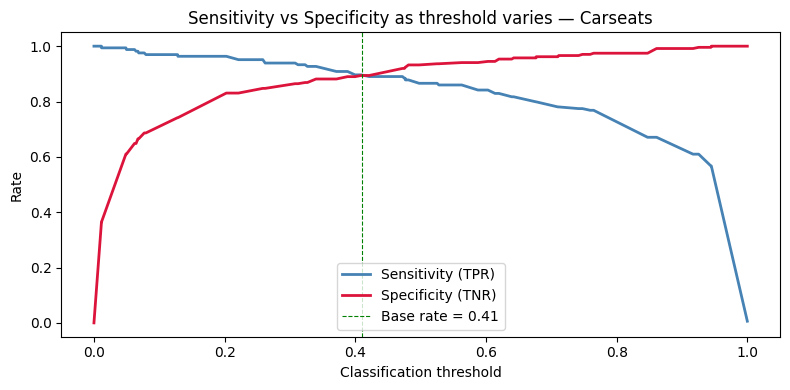

In [71]:
fpr_full, tpr_full, thresholds_full = roc_curve(y_true, y_prob_full)

# roc_curve prepends an infinite threshold; drop it before plotting against threshold
fpr_full, tpr_full, thresholds_full = fpr_full[1:], tpr_full[1:], thresholds_full[1:]
specificity_full = 1 - fpr_full
base_rate = y_true.mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds_full,
        tpr_full,
        color='steelblue',
        lw=2,
        label='Sensitivity (TPR)')
ax.plot(thresholds_full, specificity_full, color='crimson', lw=2, label='Specificity (TNR)')
ax.axvline(base_rate, color='green', ls='--', lw=0.8,
           label=f'Base rate = {base_rate:.2f}')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Rate')
ax.set_title('Sensitivity vs Specificity as threshold varies — Carseats')
ax.legend()
plt.tight_layout()
plt.show()

❓ **Question 4.2.** Based on the threshold plot and the cost reasoning above:

- If the cost of a false negative (missed high-sales location) is roughly twice the cost of a false positive, should the threshold be above or below 0.5?
- At what approximate threshold do sensitivity and specificity cross over? Is this close to the base rate?
- How does the class balance in Carseats (≈41% positive) affect the shape of the threshold plot compared to the Default dataset (≈3.3% positive)?

*Your answer here:*

1. I believe that if the cost of a false negative is higher than the cost of a false positive (twice the cost), the threshold should be lower than 0.5. With the threshold lower than 0.5, more values would be categorized as "High". According to the context, this is better than having less values being categorized as "High" because in doing so, we may accidentally miss high-sales locations

2. The sensitivity and specificity cross over at approxiately the threshold of 0.43. This is relatively close to the base rate.

3. I think that when the classes in Carseats are more balanced, the shape of the threshold plot are more symmetrical (between the left half and the right half of the shape). This occurs because when the dataset is more balanced, there is less errors in the confusion matrix - specificity: it's less likely to detect people who don't default; sensitivity: it's more likely to detect people who default.

***

# Part 5: ROC Curve and Precision-Recall Curve

## 5.1 ROC curve

### Exercise 5.1: ROC curves for both models

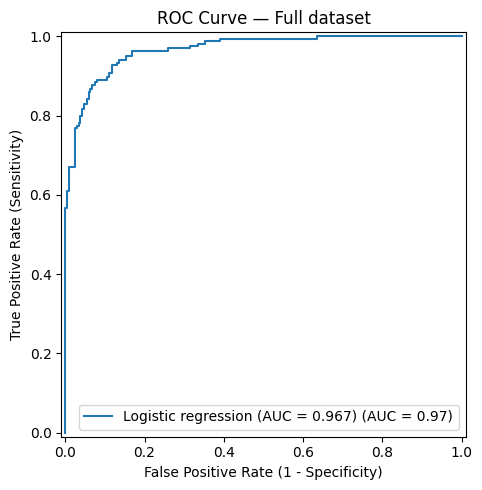

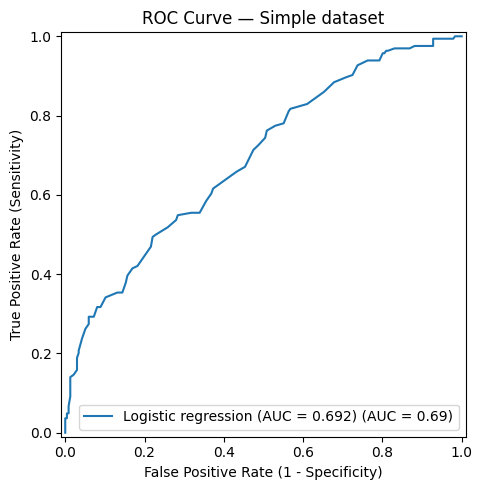

In [93]:
### YOUR CODE HERE
# (a) Compute ROC curve and AUC for model_full
# (b) Compute ROC curve and AUC for model_simple
# (c) Plot both on the same axes with the random diagonal

auc_full = roc_auc_score(y_true, y_prob_full)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_true, y_prob_full,
    name=f'Logistic regression (AUC = {auc_full:.3f})',
    ax=ax
)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Full dataset')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print()

auc_simple = roc_auc_score(y_true, y_prob_simple)

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_true, y_prob_simple,
    name=f'Logistic regression (AUC = {auc_simple:.3f})',
    ax=ax
)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — Simple dataset')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()




❓ **Question 5.1.** Interpret the AUC of `model_full`. What does a high AUC guarantee, and what does it not guarantee? How much discrimination does `Price` alone provide relative to the full model?

*Your answer here:*

The AUC of model full is approximately 0.967, this means that when picking carseats store at random, the probability that the model gives "High" sales store a higher predicted probability to be "High" sales than a "Low" sales store. In other words, in 95% random pairs of "High" sales and "Low" sales stores, the model correctly rank the "High" sale store above the "Low" sale store.

A high AUC, for instance 1, guarantee that the model would correctly identify "High" sale store and "Low" sale store.

On the other hand, a high AUC only takes into account sensitivity and specificity which may be inflated if high sensitivity/specificity is easy to maintain. AUC treats false negative and false postitives equally, when in this model, we value false negative more costly than false positives because it's more costly to miss a "High" sale store than to accidentally determine a "Low" sale store to be "High" sale store; there's larger opportunity cost. Hence, AUC does not guarantee correctness when taken opportunity costs into account, and may be inflated due to imbalance.

## 5.2 Precision-Recall curve

The Carseats dataset is roughly balanced, so the ROC curve is a reliable evaluator here, unlike the Default dataset where the class imbalance inflated the AUC. We plot the PR curve anyway to compare the two evaluation frameworks.

### Exercise 5.2: Precision-recall curve

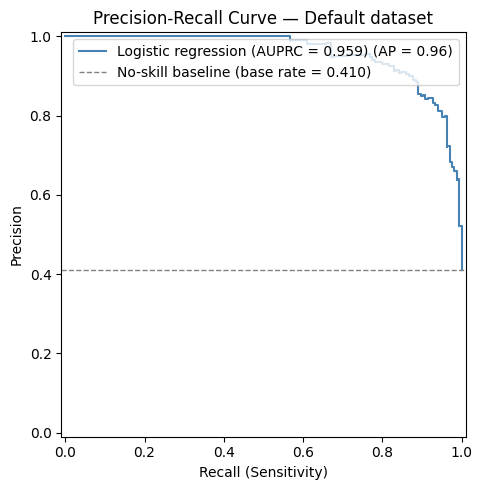

In [94]:
### YOUR CODE HERE
# (a) Compute precision-recall curve and AUPRC for model_full
# (b) Plot with the no-skill baseline (base rate horizontal line)
# (c) Label axes and add a title

auprc = average_precision_score(y_true, y_prob_full)

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_true, y_prob_full,
    name=f'Logistic regression (AUPRC = {auprc:.3f})',
    color='steelblue',
    ax=ax
)
ax.axhline(y_true.mean(),
           color='grey',
           ls='--',
           lw=1,
           label=f'No-skill baseline (base rate = {y_true.mean():.3f})')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Default dataset')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


❓ **Question 5.2.** The no-skill baseline in PR space is a horizontal line at the base rate. With a balanced dataset (base rate ≈ 0.41), how does the gap between the model curve and the baseline compare to what you would expect with a heavily imbalanced dataset like Default (base rate ≈ 0.033)? What does this tell you about when the PR curve adds the most diagnostic value over the ROC curve?

*Your answer here:*

The gap between the model curve and the baseline is lage, this indicates that our classifier is good - precision remains high as sensitivity increaeses. In a heavily imbalanced dataset like the default, the gap would be much less, where precision decrease at a faster rate towards the no-skill baseline.

The PR curve adds more dianostic value over ROC curve, specifically to identifying rare-positives datapoints by focusing entirely on the positive class, and does not meet the problem of inflation like AUC does.

***

# Checklist

Before submitting, confirm:

- [ ] Part 0: EDA completed — class distribution, Sales histogram, boxplots, crosstabs
- [ ] Part 1: Question 1.1 answered; Exercises 1.2a and 1.2b done; Questions 1.2a and 1.2b answered
- [ ] Part 2: Exercise 2.1 done; Question 2.1 answered
- [ ] Part 3: Exercise 3.1 done; Question 3.1 answered
- [ ] Part 4: Exercise 4.1 done; Questions 4.1 and 4.2 answered
- [ ] Part 5: Exercises 5.1 and 5.2 done; Questions 5.1 and 5.2 answered
- [ ] All plots have labelled axes and titles
- [ ] All written answers are in complete sentences